# OOD Unseen-Format Probe

This is an informal generalization check, not part of the official benchmark. The records use proof, critique, and derivation prompts while relying on the same discrete martingale ideas.


In [25]:
!pip install -q -U mlx-lm pandas matplotlib tqdm


In [26]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from mlx_lm import generate, load
from tqdm.auto import tqdm


In [27]:
PROJECT_ROOT = Path("/Users/xingzheli/Documents/Python-WorkSpace/SC_fine-tune")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT


PosixPath('/Users/xingzheli/Documents/Python-WorkSpace/SC_fine-tune')

In [28]:
import training_eval.eval_utils as eval_utils

importlib.reload(eval_utils)

GRADING_POLICY = eval_utils.GRADING_POLICY
extract_answer = eval_utils.extract_answer
is_correct = eval_utils.is_correct
load_jsonl_records = eval_utils.load_jsonl_records
rows_to_frame = eval_utils.rows_to_frame
save_results = eval_utils.save_results
summarize_accuracy = eval_utils.summarize_accuracy


In [29]:
MODEL_NAME = "Qwen/Qwen3-1.7B-MLX-bf16"
DATA_DIR = PROJECT_ROOT / "benchmark" / "data" / "ood_unseen_format"
RESULT_ROOT = PROJECT_ROOT / "results" / "ood_unseen_format"
ADAPTER_ROOT = PROJECT_ROOT / "results" / "fine_tunes" / "qwen3_1_7b_lora"
MAX_NEW_TOKENS = 768


In [30]:
RUNS = {
    "Qwen3 1.7B base": None,
    "LoRA algorithmic_scaffold_v2": ADAPTER_ROOT / "algorithmic_scaffold_v2" / "adapters",
    "LoRA algorithmic_scaffold_v3_5": ADAPTER_ROOT / "algorithmic_scaffold_v3_5" / "adapters",
    "LoRA algorithmic_scaffold_v3_5_lora12": ADAPTER_ROOT / "algorithmic_scaffold_v3_5_lora12" / "adapters",
}


In [31]:
records = load_jsonl_records(DATA_DIR, pattern="*.jsonl")
len(records)


20

In [32]:
pd.DataFrame(records).groupby(["answer_type", "problem_type"]).size().rename("count").reset_index()


,answer_type,problem_type,count
0,non_binary,derive_drift_compensation,1
1,non_binary,derive_exponential_base,1
2,non_binary,derive_increment_variance,1
3,non_binary,derive_quadratic_coefficient,2
4,non_binary,proof_biased_exit_probability,2
5,non_binary,proof_biased_hitting_time,3
6,non_binary,proof_bounded_stopped_value,2
7,non_binary,proof_exit_probability,1
8,non_binary,proof_expected_exit_time,1
9,non_binary,proof_finite_interval_stopped_value,1


In [33]:
FINE_TUNE_SYSTEM_MESSAGE = """You solve discrete stochastic-process problems. Give concise reasoning, then end with exactly one final answer block: Final answer:
<answer>
{...}
</answer>. Do not write anything after </answer>."""


In [34]:
def make_fine_tuned_chat_messages(problem):
    return [
        {"role": "system", "content": FINE_TUNE_SYSTEM_MESSAGE},
        {"role": "user", "content": problem},
    ]


In [35]:
def make_qwen_prompt(tokenizer, problem):
    messages = make_fine_tuned_chat_messages(problem)
    try:
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    except TypeError:
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


In [36]:
def load_run_model(adapter_path):
    if adapter_path is None:
        return load(MODEL_NAME)
    return load(MODEL_NAME, adapter_path=str(adapter_path))


In [37]:
def generate_answer(model, tokenizer, problem):
    prompt = make_qwen_prompt(tokenizer, problem)
    return generate(model, tokenizer, prompt=prompt, max_tokens=MAX_NEW_TOKENS, verbose=False)


In [38]:
def evaluate_run(run_label, adapter_path, records):
    model, tokenizer = load_run_model(adapter_path)
    rows = []

    for record in tqdm(records, desc=run_label):
        raw_output = generate_answer(model, tokenizer, record["problem"])
        predicted = extract_answer(raw_output, record["canonical_answer"])
        rows.append({
            "run": run_label,
            "id": record["id"],
            "family": record["family"],
            "problem_type": record["problem_type"],
            "difficulty": record["difficulty"],
            "answer_type": record["answer_type"],
            "problem": record["problem"],
            "canonical_answer": record["canonical_answer"],
            "raw_output": raw_output,
            "predicted_answer": predicted,
            "correct": is_correct(predicted, record["canonical_answer"]),
        })

    return rows


In [39]:
def save_run(run_label, rows):
    safe_label = run_label.lower().replace(" ", "_").replace("/", "_")
    result_dir = RESULT_ROOT / safe_label
    df = rows_to_frame(rows)
    metrics = summarize_accuracy(df)
    metrics.update({
        "model": MODEL_NAME,
        "run": run_label,
        "dataset": "benchmark/data/ood_unseen_format/*.jsonl",
        "grading_policy": GRADING_POLICY,
    })
    save_results(rows, result_dir, metrics)
    return result_dir


## Run Probe

This evaluates the base model and any listed adapters whose folders exist. Re-running overwrites the same OOD result folders.


In [40]:
all_rows = []

for run_label, adapter_path in RUNS.items():
    if adapter_path is not None and not adapter_path.exists():
        print(f"Skipping missing adapter: {run_label} -> {adapter_path}")
        continue
    rows = evaluate_run(run_label, adapter_path, records)
    save_run(run_label, rows)
    all_rows.extend(rows)

df = rows_to_frame(all_rows)
df.head()


LoRA algorithmic_scaffold_v3_5_lora12: 100%|██████████| 20/20 [29:51<00:00, 89.58s/it] 


,run,id,family,problem_type,difficulty,answer_type,problem,canonical_answer,raw_output,predicted_answer,correct
0,Qwen3 1.7B base,ood_proof_0001,ood_unseen_format,proof_exit_probability,2,non_binary,Proof-style prompt. A fair nearest-neighbor wa...,{'probability': '2/7'},Let $ X_n $ be the position of the walk at tim...,None,False
1,Qwen3 1.7B base,ood_proof_0002,ood_unseen_format,proof_expected_exit_time,2,non_binary,Derivation prompt. For a fair simple random wa...,{'expected_time': '10'},The quadratic martingale for a fair simple ran...,{'expected_time': 4},False
2,Qwen3 1.7B base,ood_proof_0003,ood_unseen_format,proof_biased_hitting_time,3,non_binary,"A biased nearest-neighbor walk starts at 1, mo...",{'expected_time': '15/7'},"To solve this problem, we use the exponential ...",{'expected_time': '9/19'},False
3,Qwen3 1.7B base,ood_proof_0004,ood_unseen_format,proof_bounded_stopped_value,1,non_binary,A fair walk starts at -2. Let T be the first v...,{'value': '-2'},The expected value of the stopped walk is the ...,{'value': 0},False
4,Qwen3 1.7B base,ood_proof_0005,ood_unseen_format,derive_quadratic_coefficient,2,non_binary,Let S_n be a fair walk with increments +3 or -...,{'coefficient': '9'},To find the constant $ c $ such that $ S_n^2 -...,{'coefficient': '0'},False


## Tables


In [41]:
summary_df = (
    df.groupby("run")["correct"]
    .agg(accuracy="mean", correct="sum", count="count")
    .reset_index()
    .sort_values("accuracy", ascending=False)
)

answer_type_df = (
    df.groupby(["run", "answer_type"])["correct"]
    .agg(accuracy="mean", correct="sum", count="count")
    .reset_index()
    .sort_values(["answer_type", "accuracy"], ascending=[True, False])
)

problem_type_df = (
    df.groupby(["run", "answer_type", "problem_type"])["correct"]
    .agg(accuracy="mean", correct="sum", count="count")
    .reset_index()
    .sort_values(["answer_type", "problem_type", "accuracy"], ascending=[True, True, False])
)

display(summary_df)
display(answer_type_df)
problem_type_df


,run,accuracy,correct,count
0,LoRA algorithmic_scaffold_v2,0.25,5,20
1,LoRA algorithmic_scaffold_v3_5,0.20,4,20
2,LoRA algorithmic_scaffold_v3_5_lora12,0.15,3,20
3,Qwen3 1.7B base,0.10,2,20


,run,answer_type,accuracy,correct,count
0,LoRA algorithmic_scaffold_v2,non_binary,0.25,5,20
1,LoRA algorithmic_scaffold_v3_5,non_binary,0.20,4,20
2,LoRA algorithmic_scaffold_v3_5_lora12,non_binary,0.15,3,20
3,Qwen3 1.7B base,non_binary,0.10,2,20


,run,answer_type,problem_type,accuracy,correct,count
0,LoRA algorithmic_scaffold_v2,non_binary,derive_drift_compensation,1.0,1,1
13,LoRA algorithmic_scaffold_v3_5,non_binary,derive_drift_compensation,0.0,0,1
26,LoRA algorithmic_scaffold_v3_5_lora12,non_binary,derive_drift_compensation,0.0,0,1
39,Qwen3 1.7B base,non_binary,derive_drift_compensation,0.0,0,1
1,LoRA algorithmic_scaffold_v2,non_binary,derive_exponential_base,0.0,0,1
14,LoRA algorithmic_scaffold_v3_5,non_binary,derive_exponential_base,0.0,0,1
27,LoRA algorithmic_scaffold_v3_5_lora12,non_binary,derive_exponential_base,0.0,0,1
40,Qwen3 1.7B base,non_binary,derive_exponential_base,0.0,0,1
2,LoRA algorithmic_scaffold_v2,non_binary,derive_increment_variance,1.0,1,1
15,LoRA algorithmic_scaffold_v3_5,non_binary,derive_increment_variance,1.0,1,1


## Charts


In [42]:
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ORDER = summary_df["run"].tolist()


In [43]:
def plot_answer_type_accuracy(answer_type_df):
    plot_df = answer_type_df.pivot(index="run", columns="answer_type", values="accuracy")
    plot_df = plot_df.reindex([run for run in RUN_ORDER if run in plot_df.index])
    ax = plot_df.plot(kind="bar", figsize=(10, 4.5), ylim=(0, 1), width=0.82)
    ax.set_title("OOD proof-style accuracy by answer type")
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy")
    ax.axhline(0.5, color="0.75", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig(RESULT_ROOT / "ood_accuracy_by_answer_type.png", dpi=180)
    plt.show()


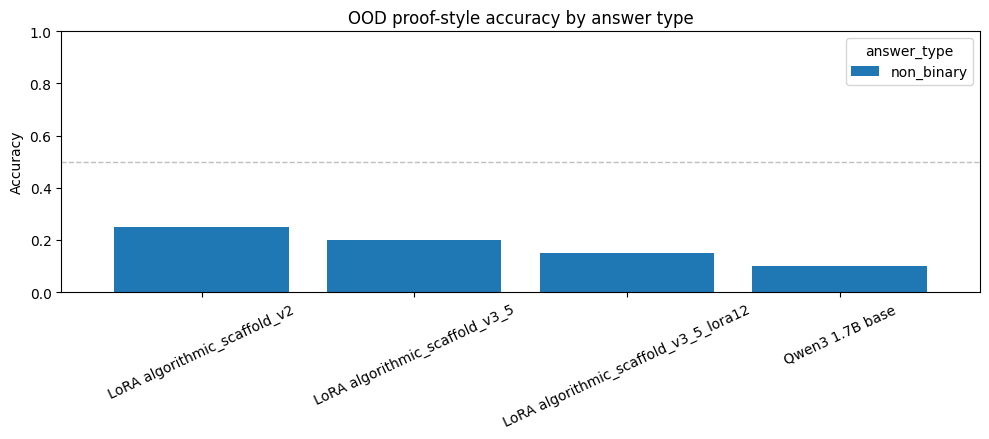

In [44]:
plot_answer_type_accuracy(answer_type_df)


In [45]:
def plot_problem_type_heatmap(problem_type_df, answer_type):
    plot_df = problem_type_df[problem_type_df["answer_type"] == answer_type]
    if plot_df.empty:
        print(f"No {answer_type} rows to plot.")
        return

    matrix = plot_df.pivot(index="problem_type", columns="run", values="accuracy")
    matrix = matrix[[run for run in RUN_ORDER if run in matrix.columns]]

    fig, ax = plt.subplots(figsize=(max(8, 0.8 * len(matrix.columns)), max(4, 0.35 * len(matrix.index))))
    image = ax.imshow(matrix.fillna(0), vmin=0, vmax=1, aspect="auto", cmap="RdYlGn")
    ax.set_title(f"OOD {answer_type.replace('_', '-')} accuracy by problem type")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)

    for i, problem_type in enumerate(matrix.index):
        for j, run in enumerate(matrix.columns):
            value = matrix.loc[problem_type, run]
            if pd.notna(value):
                ax.text(j, i, f"{value:.0%}", ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, label="Accuracy")
    plt.tight_layout()
    plt.savefig(RESULT_ROOT / f"ood_accuracy_by_problem_type_{answer_type}.png", dpi=180)
    plt.show()


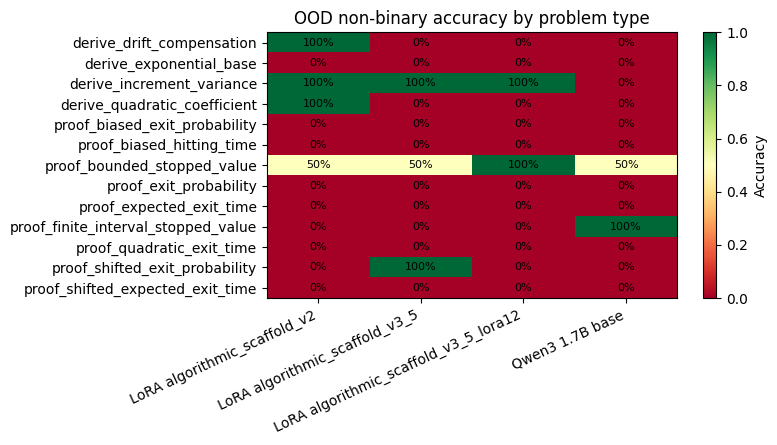

In [46]:
for answer_type in sorted(problem_type_df["answer_type"].unique()):
    plot_problem_type_heatmap(problem_type_df, answer_type)


In [47]:
summary_df.to_csv(RESULT_ROOT / "summary.csv", index=False)
answer_type_df.to_csv(RESULT_ROOT / "by_answer_type.csv", index=False)
problem_type_df.to_csv(RESULT_ROOT / "by_problem_type.csv", index=False)
df.to_csv(RESULT_ROOT / "all_outputs.csv", index=False)
RESULT_ROOT


PosixPath('/Users/xingzheli/Documents/Python-WorkSpace/SC_fine-tune/results/ood_unseen_format')

## Inspect Misses


In [48]:
df.loc[
    ~df["correct"],
    ["run", "id", "answer_type", "problem_type", "canonical_answer", "predicted_answer", "raw_output"],
]


,run,id,answer_type,problem_type,canonical_answer,predicted_answer,raw_output
0,Qwen3 1.7B base,ood_proof_0001,non_binary,proof_exit_probability,{'probability': '2/7'},None,Let $ X_n $ be the position of the walk at tim...
1,Qwen3 1.7B base,ood_proof_0002,non_binary,proof_expected_exit_time,{'expected_time': '10'},{'expected_time': 4},The quadratic martingale for a fair simple ran...
2,Qwen3 1.7B base,ood_proof_0003,non_binary,proof_biased_hitting_time,{'expected_time': '15/7'},{'expected_time': '9/19'},"To solve this problem, we use the exponential ..."
3,Qwen3 1.7B base,ood_proof_0004,non_binary,proof_bounded_stopped_value,{'value': '-2'},{'value': 0},The expected value of the stopped walk is the ...
4,Qwen3 1.7B base,ood_proof_0005,non_binary,derive_quadratic_coefficient,{'coefficient': '9'},{'coefficient': '0'},To find the constant $ c $ such that $ S_n^2 -...
...,...,...,...,...,...,...,...
75,LoRA algorithmic_scaffold_v3_5_lora12,ood_proof_0016,non_binary,proof_finite_interval_stopped_value,{'value': '3'},{'value': '8'},Step 1: Identify the stopped process.\nThe wal...
76,LoRA algorithmic_scaffold_v3_5_lora12,ood_proof_0017,non_binary,proof_shifted_exit_probability,{'probability': '5/8'},{'probability': '0'},Step 1: Identify the walk type.\nThe walk is b...
77,LoRA algorithmic_scaffold_v3_5_lora12,ood_proof_0018,non_binary,proof_shifted_expected_exit_time,{'expected_time': '15'},{'expected_time': '0.5*(3 - (-5))*((0)^2 - (-5...,Step 1: Identify the stopped quadratic marting...
78,LoRA algorithmic_scaffold_v3_5_lora12,ood_proof_0019,non_binary,proof_biased_exit_probability,{'probability': '9/10'},{'probability': '0'},Step 1: Identify the walk parameters.\nThe wal...
